<a href="https://www.kaggle.com/code/jasminemohamed2545/plant-disease-guide-98-acc-cnn-vgg-resnet?scriptVersionId=264414585" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🌿 AgroScanAI: Plant Disease Showdown (CNN vs VGG vs ResNet) 🚀

### Can we teach a machine to be a digital farmer? A deep dive into classifying plant diseases with an accuracy of over 97%!

Welcome to this comprehensive analysis where we tackle a critical real-world problem: automated plant disease detection. Early and accurate diagnosis of diseases like rust and powdery mildew can save entire harvests, ensuring food security and reducing economic losses for farmers. 🌾

In this notebook, we'll embark on a journey from raw leaf images to a highly accurate classification model. We won't just build one model; we'll stage a showdown between three powerful computer vision architectures to see which one reigns supreme!

## 🎯 What's Inside This Notebook?

Here’s a roadmap of our adventure:

#### 1. 📊 Exploratory Data Analysis (EDA)
We'll start by getting to know our dataset. How many images do we have? Is the data balanced? We'll visualize sample images and class distributions to build our intuition.

#### 2. 🔧 Preprocessing & Augmentation
Preparing our image data is crucial. We'll explore image preprocessing and augmentation techniques to create a robust training pipeline.

#### 3. 🏗️ Model #1: A Custom CNN from Scratch
We'll roll up our sleeves and build a Convolutional Neural Network from the ground up to understand the core mechanics.

#### 4. 🎨 Model #2: Fine-Tuning VGG16
Next, we'll leverage the power of Transfer Learning by fine-tuning the legendary VGG16 model. Can a pre-trained model give us a head start?

#### 5. 🏆 Model #3: Unleashing ResNet50
We'll bring out the heavyweight champion, ResNet50, known for its deep residual networks. This is where things get serious!

#### 6. 📈 Results & Showdown
Finally, we'll compare all three models based on their accuracy, loss, and classification reports. We'll visualize the results with confusion matrices and declare a winner.

#### If you find this notebook insightful or learn something new, an upvote would be greatly appreciated! 👍 It helps others discover this work. Let's get started!

In [8]:
import kagglehub
rashikrahmanpritom_plant_disease_recognition_dataset_path = kagglehub.dataset_download('rashikrahmanpritom/plant-disease-recognition-dataset')

print('Data source import complete.')


Data source import complete.


In [9]:
import pandas as pd
import cv2
import os
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.applications import VGG16, ResNet50, MobileNet, InceptionV3, DenseNet201
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import *

In [10]:
path = rashikrahmanpritom_plant_disease_recognition_dataset_path

for item in os.listdir(path):
    print(item)
    print("Is folder:", os.path.isdir(os.path.join(path, item)))

Validation
Is folder: True
Test
Is folder: True
Train
Is folder: True


In [11]:
def loadingData(DSpath, imagesize =(224, 224)):
    imgs, lbls = [], []
    for cls in sorted(os.listdir(DSpath)):
        clspath = os.path.join(DSpath, cls)
        if not os.path.isdir(clspath): continue
        for imgnm in os.listdir(clspath):
            img = cv2.imread(os.path.join(clspath,imgnm))
            if img is not None:
                imgs.append(cv2.resize(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), imagesize))
                lbls.append(cls)

    return np.array(imgs), np.array(lbls)


# Loading Data to a train path, validation path, test path

In [12]:
base = rashikrahmanpritom_plant_disease_recognition_dataset_path
trainpth, valpth, testpth = [os.path.join(base, x) for x in ['Train/Train', 'Validation/Validation', 'Test/Test']]

# EDA

In [13]:
# How many files found in each path
def count_images_in_folder(folder_path):
    total = 0
    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)
        total += len(os.listdir(class_folder))
    return total

train_count = count_images_in_folder(trainpth)
val_count = count_images_in_folder(valpth)
test_count = count_images_in_folder(testpth)

print(f"Train images: {train_count}")
print(f"Validation images: {val_count}")
print(f"Test images: {test_count}")

Train images: 1322
Validation images: 60
Test images: 150


In [14]:
# How many classes in the train path
for class_name in os.listdir(trainpth):
    class_folder = os.path.join(trainpth, class_name)
    files = os.listdir(class_folder)
    print(f"{class_name}: {len(files)} images")

Healthy: 458 images
Rust: 434 images
Powdery: 430 images


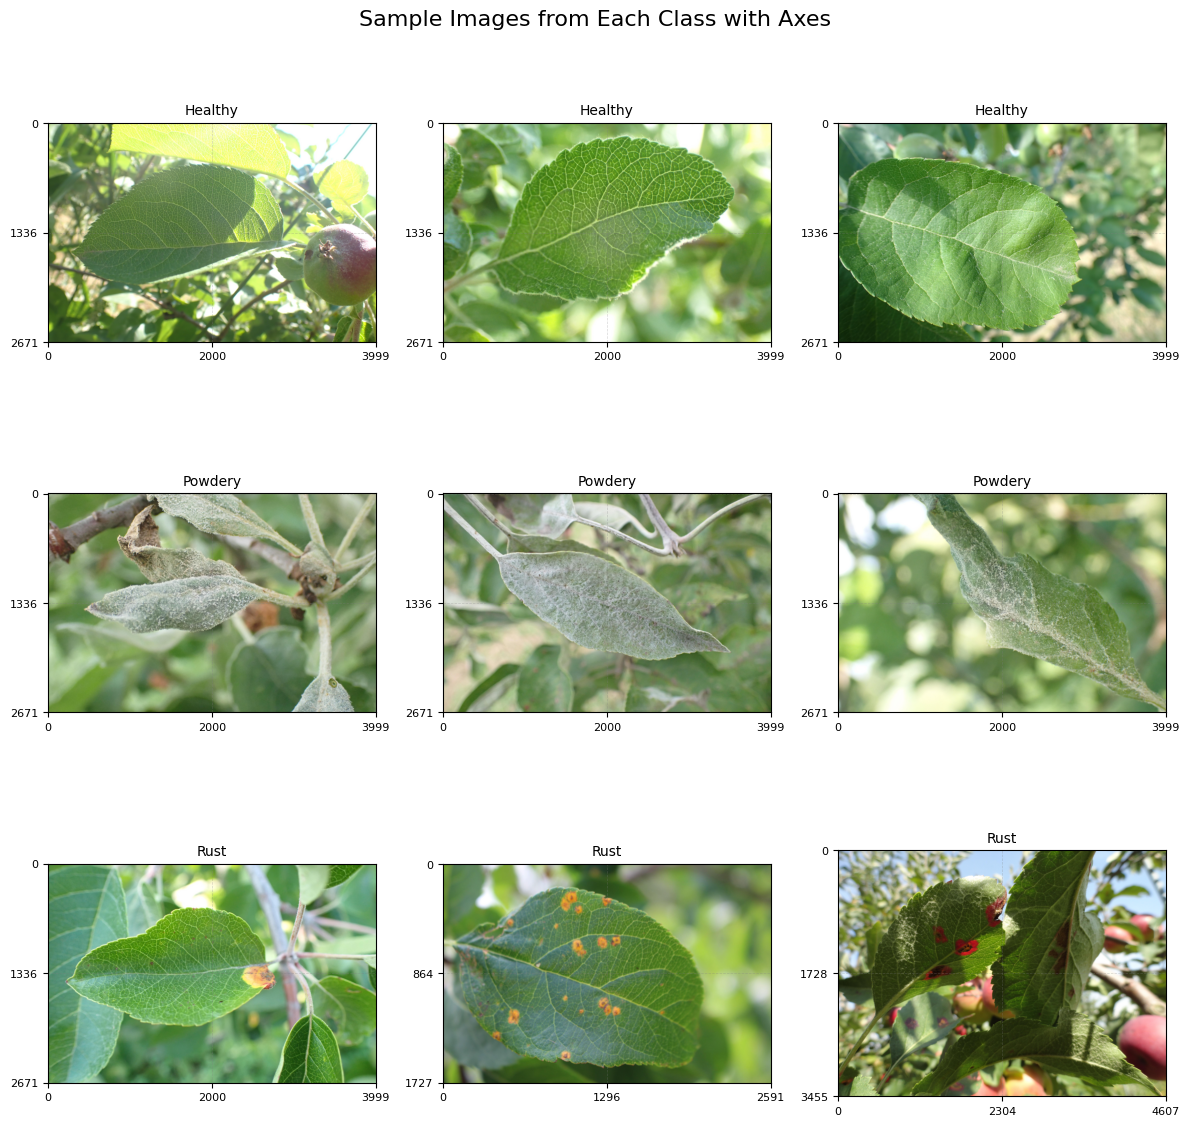

In [15]:
import cv2
import os
import matplotlib.pyplot as plt

def show_sample_images_with_axes(data_path, classes, image_per_class=2):
    fig, axs = plt.subplots(len(classes), image_per_class, figsize=(image_per_class * 4, len(classes) * 4))

    if len(classes) == 1:
        axs = [axs]  # handle when there is only one class
    elif image_per_class == 1:
        axs = [[ax] for ax in axs]  # handle 1 column

    for i, class_name in enumerate(classes):
        class_folder = os.path.join(data_path, class_name)
        images = os.listdir(class_folder)[:image_per_class]

        for j, img_name in enumerate(images):
            img_path = os.path.join(class_folder, img_name)
            img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

            ax = axs[i][j]
            ax.imshow(img)
            ax.set_title(f"{class_name}", fontsize=10)
            ax.set_xticks([0, img.shape[1]//2, img.shape[1]-1])
            ax.set_yticks([0, img.shape[0]//2, img.shape[0]-1])
            ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=8)

    plt.suptitle("Sample Images from Each Class with Axes", fontsize=16)
    plt.tight_layout()
    plt.show()

show_sample_images_with_axes(trainpth, ['Healthy', 'Powdery', 'Rust'], image_per_class=3)

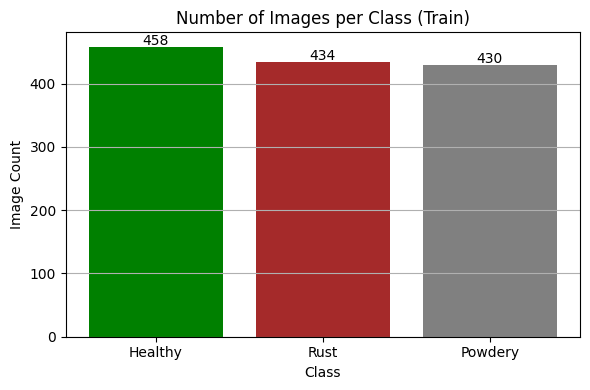

In [16]:
# Visualizing classes imbalances
import os
import matplotlib.pyplot as plt
import numpy as np

class_counts = {}
for class_name in os.listdir(trainpth):
    class_folder = os.path.join(trainpth, class_name)
    if os.path.isdir(class_folder):
        class_counts[class_name] = len(os.listdir(class_folder))

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(6,4))
plt.bar(classes, counts, color=['green', 'brown', 'grey'])
plt.title('Number of Images per Class (Train)')
plt.xlabel('Class')
plt.ylabel('Image Count')
plt.grid(axis='y')

for i in range(len(classes)):
    plt.text(i, counts[i] + 3, str(counts[i]), ha='center')

plt.tight_layout()
plt.show()

# Splitting data found in each path to features(x) and target(y)

In [16]:
x_train_origin, y_train = loadingData(trainpth)
x_val_origin, y_val = loadingData(valpth)
x_test_origin, y_test = loadingData(testpth)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded = le.transform(y_val)
y_test_encoded = le.transform(y_test)

In [17]:
num_classes = len(np.unique(y_train_encoded))
print(f"{num_classes} unique classes in data.")

3 unique classes in data.


In [19]:
print("Classes mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Classes mapping: {'Healthy': 0, 'Powdery': 1, 'Rust': 2}


# Preprocessing

In [19]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

def DataGenerator(model='CNN'):
    if model == 'VGG':
        preprocessing = vgg_preprocess
        rescale = None
    elif model == 'ResNet50':
        preprocessing = resnet_preprocess
        rescale = None
    else:
        raise ValueError("Invalid model name")

    datagen = ImageDataGenerator(
        rotation_range=20,
        validation_split=0.2,
        width_shift_range=0.2,
        height_shift_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        rescale=rescale,
        preprocessing_function=preprocessing
    )

    return datagen

# Custom CNN

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD

# Define your model
model_CNN = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')  
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1757628190.481097      60 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1757628190.481765      60 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [21]:
from tensorflow.keras.optimizers import Adam
model_CNN.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

In [23]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen_cnn_train = ImageDataGenerator(rescale=1.0 / 255.0)
train_generator = datagen_cnn_train.flow(x_train_origin, y_train_encoded, batch_size=64, shuffle=True)
datagen_cnn_val = ImageDataGenerator(rescale=1.0 / 255.0)
val_generator = datagen_cnn_val.flow(x_val_origin, y_val_encoded, batch_size=64, shuffle=False)

In [24]:
history = model_CNN.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1757628208.171739     118 service.cc:148] XLA service 0x7faaf0002870 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757628208.172662     118 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1757628208.172689     118 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1757628208.660627     118 cuda_dnn.cc:529] Loaded cuDNN version 90300


 1/21 ━━━━━━━━━━━━━━━━━━━━ 4:48 14s/step - accuracy: 0.4531 - loss: 1.6642

I0000 00:00:1757628218.113427     118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


21/21 ━━━━━━━━━━━━━━━━━━━━ 26s 603ms/step - accuracy: 0.6644 - loss: 7.5600 - val_accuracy: 0.3333 - val_loss: 13.6593
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.8922 - loss: 1.4979 - val_accuracy: 0.3333 - val_loss: 21.1974
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - accuracy: 0.9422 - loss: 0.7195 - val_accuracy: 0.4833 - val_loss: 5.8371
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.9542 - loss: 0.3997 - val_accuracy: 0.3500 - val_loss: 16.1721
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.9624 - loss: 0.3281 - val_accuracy: 0.3833 - val_loss: 18.3716
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9785 - loss: 0.1639 - val_accuracy: 0.3667 - val_loss: 16.4580
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - accuracy: 0.9701 - loss: 0.2273 - val_accuracy: 0.3500 - val_loss: 19.4513
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.9805 - loss: 0.1261 - val_accuracy: 0.4333

In [28]:
model_CNN.save('best_cnn_model.h5')

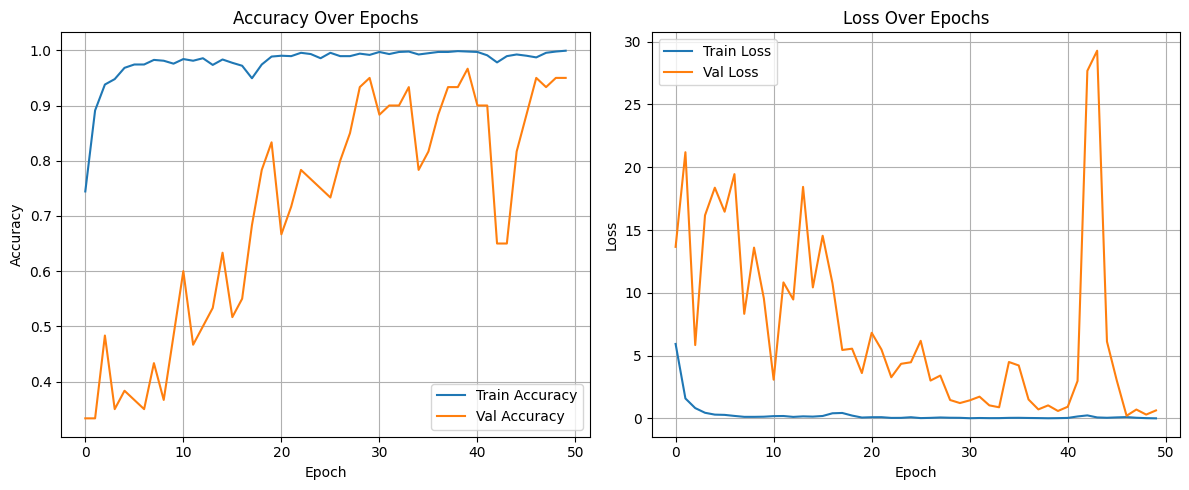

In [29]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [34]:
datagen_CNN_test = ImageDataGenerator(rescale=1.0 / 255.0)
test_generator_CNN = datagen_CNN_test.flow(x_test_origin, y_test_encoded, batch_size=64, shuffle=False)

# Predict
y_pred_probs_CNN = model_CNN.predict(test_generator_CNN)
y_pred_CNN = np.argmax(y_pred_probs_CNN, axis=1)
y_true = y_test_encoded

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 709ms/step


In [38]:
model_CNN.evaluate(test_generator_CNN)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 231ms/step - accuracy: 0.9471 - loss: 1.5861


[1.8530389070510864, 0.9333333373069763]

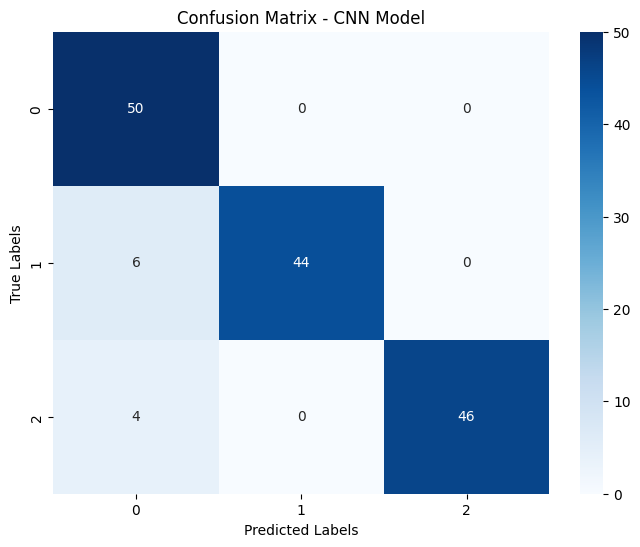

              precision    recall  f1-score   support

     class_0       0.83      1.00      0.91        50
     class_1       1.00      0.88      0.94        50
     class_2       1.00      0.92      0.96        50

    accuracy                           0.93       150
   macro avg       0.94      0.93      0.93       150
weighted avg       0.94      0.93      0.93       150



In [35]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_CNN)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - CNN Model')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report
class_names = ['class_0', 'class_1', 'class_2']
report = classification_report(y_true, y_pred_CNN, target_names=class_names)
print(report)

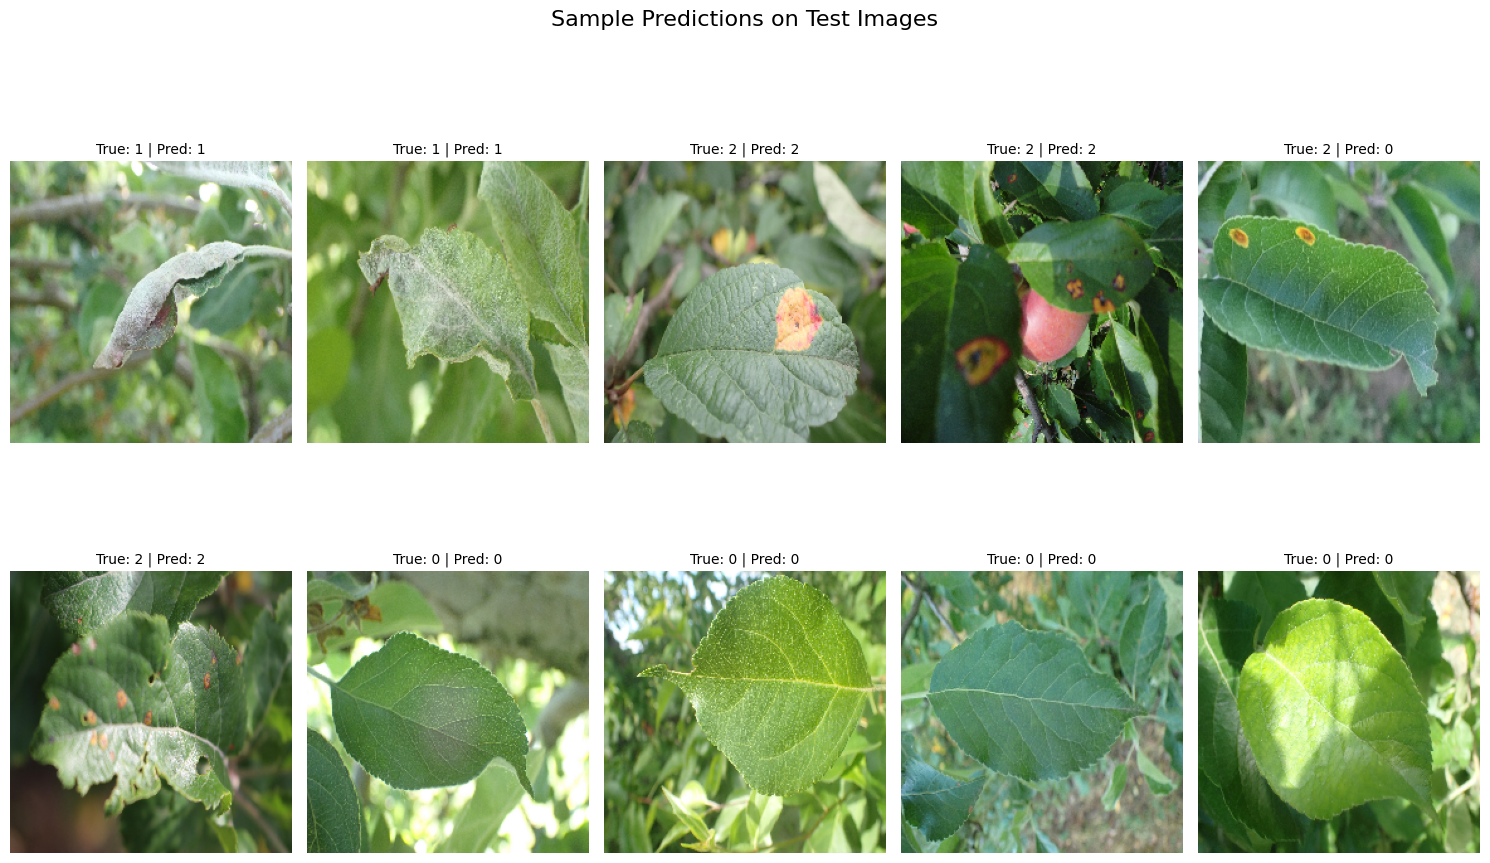

In [36]:
num_samples = 10

indices = np.random.choice(len(x_test_origin), num_samples, replace=False)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    img = x_test_origin[idx]
    true_label = y_test_encoded[idx]
    pred_label = y_pred_CNN[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img.astype('uint8'))
    plt.axis('off')
    true_name = le.inverse_transform([true_label])[0]
    pred_name = le.inverse_transform([pred_label])[0]
    plt.title(f"True: {true_name} | Pred: {pred_name}", fontsize=10)
    plt.title(f"True: {true_label} | Pred: {pred_label}", fontsize=10)

plt.suptitle("Sample Predictions on Test Images", fontsize=16)
plt.tight_layout()
plt.show()

# VGG Model

In [41]:
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers[:10]:
    layer.trainable = False

for layer in base_model.layers[10:]:
    layer.trainable = True
model_VGG = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [42]:
model_VGG.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [43]:
callbacky =[
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
    ]

In [44]:
datagen_vgg_train = DataGenerator(model='VGG')
train_generator_vgg = datagen_vgg_train.flow(x_train_origin, y_train_encoded, batch_size=64, shuffle=True)

datagen_vgg_val = DataGenerator(model='VGG')
val_generator_vgg = datagen_vgg_val.flow(x_val_origin, y_val_encoded, batch_size=64, shuffle=False)

In [46]:
history = model_VGG.fit(
  train_generator_vgg,
  validation_data=val_generator_vgg,
  epochs=30,
  batch_size=64
  )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


2025-08-19 09:46:01.921643: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng36{k2=3,k3=0} for conv (f32[64,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0","wait_on_operation_queues":[]} is taking a while...
2025-08-19 09:46:02.052277: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 1.130734122s
Trying algorithm eng36{k2=3,k3=0} for conv (f32[64,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,64,224,224]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationF

21/21 ━━━━━━━━━━━━━━━━━━━━ 91s 3s/step - accuracy: 0.4041 - loss: 1.3696 - val_accuracy: 0.3333 - val_loss: 24.5980
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 707ms/step - accuracy: 0.4790 - loss: 1.0742 - val_accuracy: 0.3333 - val_loss: 15.4599
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 701ms/step - accuracy: 0.5713 - loss: 0.8607 - val_accuracy: 0.5000 - val_loss: 63.0061
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 684ms/step - accuracy: 0.6359 - loss: 0.6856 - val_accuracy: 0.5167 - val_loss: 1.8887
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 696ms/step - accuracy: 0.7226 - loss: 0.5678 - val_accuracy: 0.5833 - val_loss: 0.7491
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 692ms/step - accuracy: 0.7628 - loss: 0.5221 - val_accuracy: 0.6833 - val_loss: 0.7101
Epoch 7/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 695ms/step - accuracy: 0.8254 - loss: 0.4483 - val_accuracy: 0.3833 - val_loss: 1.7458
Epoch 8/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 15s 696ms/step - accuracy: 0.8782 - loss: 0.3707 - val_accuracy: 0.383

In [47]:
import numpy as np

# Save history for later use
np.save('vgg_history.npy', history.history)

In [48]:
model_VGG.save('vgg_model_full.h5')

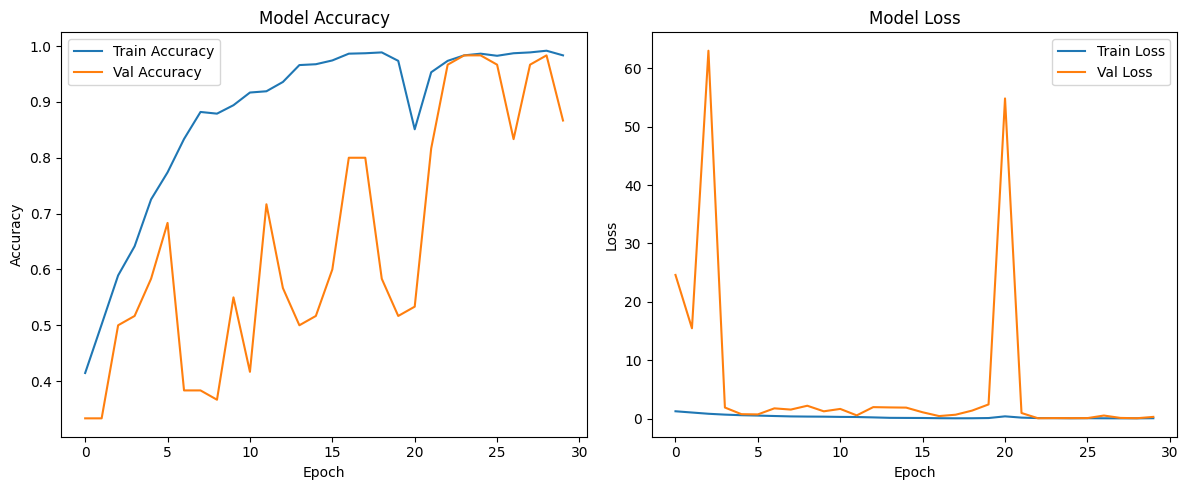

In [49]:
import matplotlib.pyplot as plt

history_dict = history.history

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [50]:
datagen_vgg_test = DataGenerator(model='VGG')
test_generator_vgg = datagen_vgg_test.flow(x_test_origin, y_test_encoded, batch_size=64, shuffle=False)

# Predict
y_pred_probs = model_VGG.predict(test_generator_vgg)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_encoded

3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 5s/step 


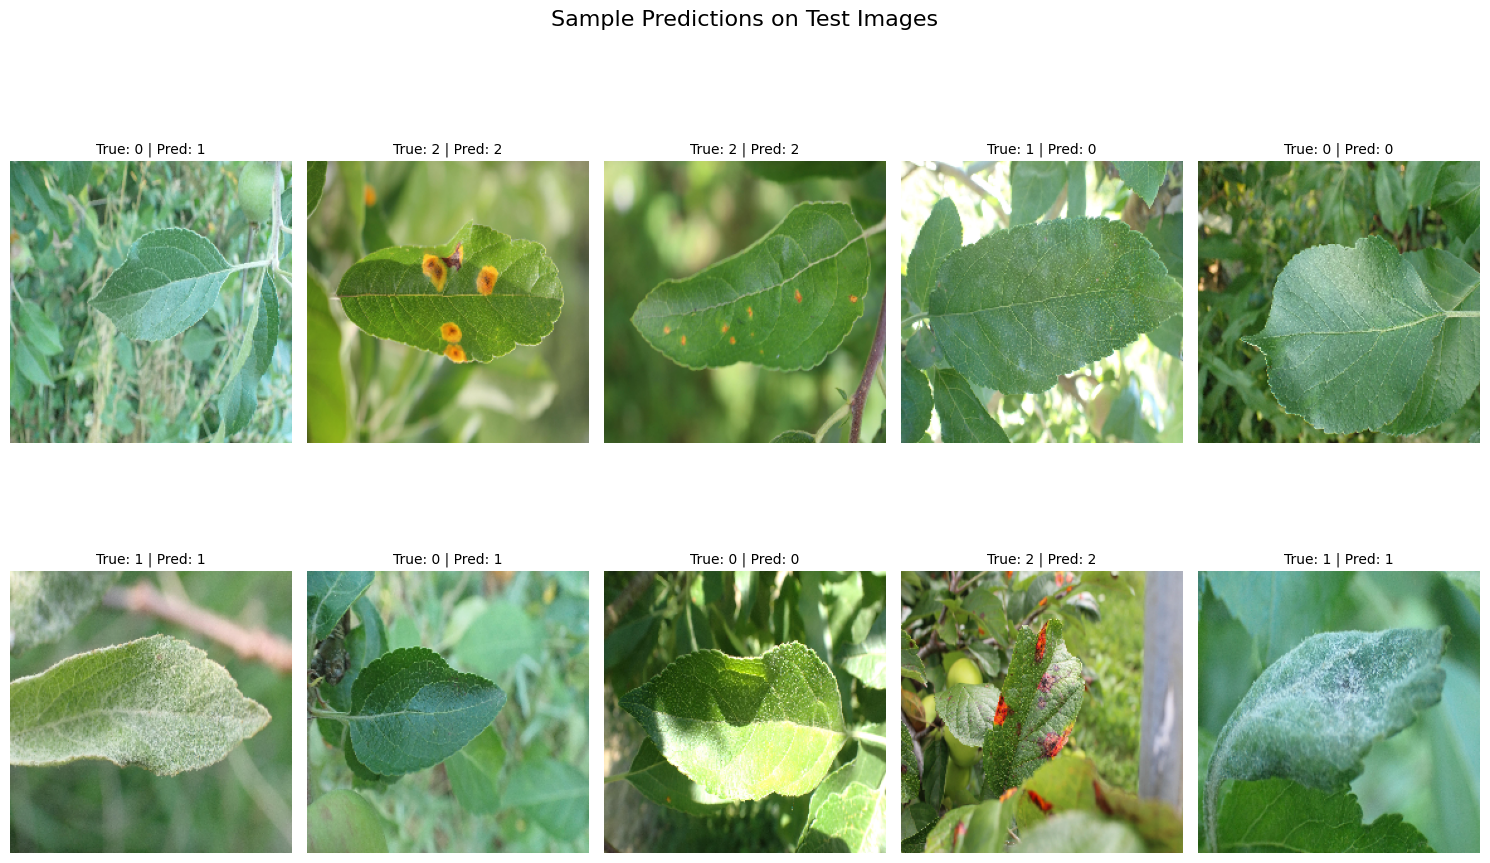

In [51]:
num_samples = 10

indices = np.random.choice(len(x_test_origin), num_samples, replace=False)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    img = x_test_origin[idx]
    true_label = y_test_encoded[idx]
    pred_label = y_pred[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img.astype('uint8'))
    plt.axis('off')
    true_name = le.inverse_transform([true_label])[0]
    pred_name = le.inverse_transform([pred_label])[0]
    plt.title(f"True: {true_name} | Pred: {pred_name}", fontsize=10)
    plt.title(f"True: {true_label} | Pred: {pred_label}", fontsize=10)

plt.suptitle("Sample Predictions on Test Images", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
y_true = y_test_encoded

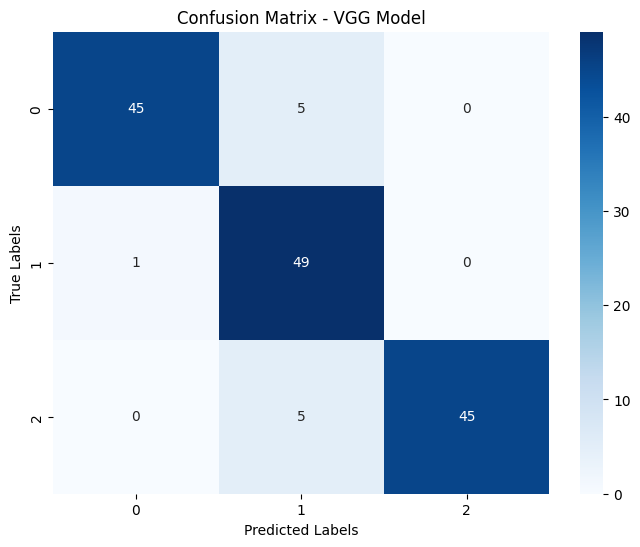

              precision    recall  f1-score   support

     class_0       0.98      0.90      0.94        50
     class_1       0.83      0.98      0.90        50
     class_2       1.00      0.90      0.95        50

    accuracy                           0.93       150
   macro avg       0.94      0.93      0.93       150
weighted avg       0.94      0.93      0.93       150



In [53]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - VGG Model')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report
class_names = ['class_0', 'class_1', 'class_2']  
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# ResNet50

In [54]:
base_model_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in base_model_res.layers[:100]:
    layer.trainable = False
for layer in base_model_res.layers[100:]:
    layer.trainable = True


model_RES = Sequential([
    base_model_res,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [55]:
from tensorflow.keras.optimizers import SGD

optimizer_res = SGD(learning_rate=0.01, momentum=0.9)

model_RES.compile(
    optimizer=optimizer_res,
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [56]:
callbacky_res = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint('best_resnet_model.h5', save_best_only=True)
]

In [57]:
datagen_res_train = DataGenerator(model='ResNet50')
train_generator_res = datagen_res_train.flow(x_train_origin, y_train_encoded, batch_size=16, shuffle=True)

datagen_res_val = DataGenerator(model='ResNet50')
val_generator_res = datagen_res_val.flow(x_val_origin, y_val_encoded, batch_size=64, shuffle=False)

In [58]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [59]:
history_res = model_RES.fit(
    train_generator_res,
    validation_data=val_generator_res,
    epochs=10,
    callbacks=callbacky_res
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


83/83 ━━━━━━━━━━━━━━━━━━━━ 56s 638ms/step - accuracy: 0.8652 - loss: 0.4190 - val_accuracy: 0.9000 - val_loss: 0.4252
Epoch 2/2
83/83 ━━━━━━━━━━━━━━━━━━━━ 51s 611ms/step - accuracy: 0.9662 - loss: 0.1069 - val_accuracy: 0.9667 - val_loss: 0.0822


In [60]:
import numpy as np
np.save('resnet_history.npy', history_res.history)

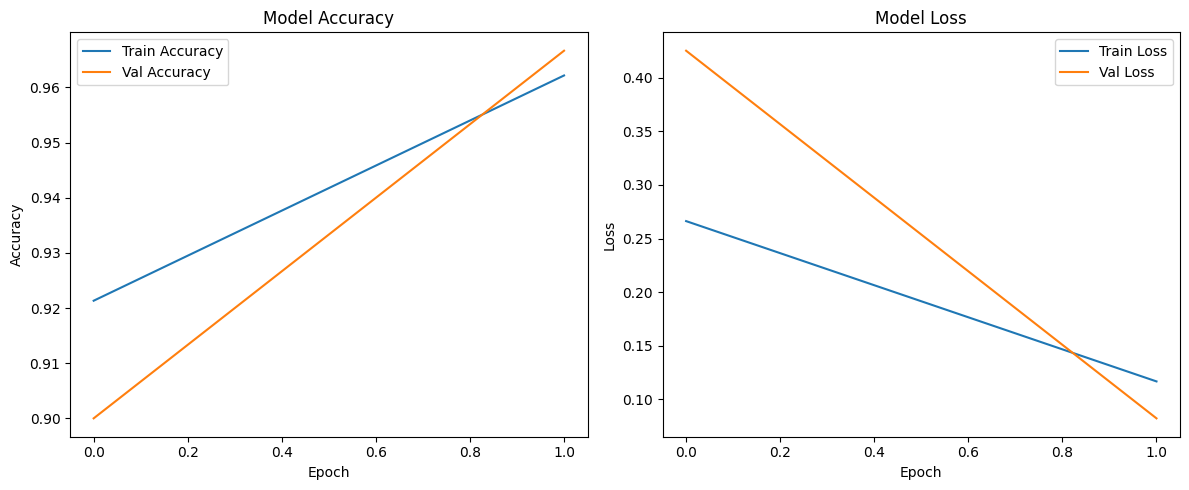

In [61]:
import matplotlib.pyplot as plt

history_dict = history_res.history

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [62]:
y_pred_probs_Res= model_RES.predict(x_train_origin)
y_pred_Res = np.argmax(y_pred_probs_Res, axis=1)

42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step


In [63]:
datagen_Res_test = DataGenerator(model='ResNet50')
test_generator_Res = datagen_Res_test.flow(x_test_origin, y_test_encoded, batch_size=64, shuffle=False)

# Predict
y_pred_probs_Res = model_RES.predict(test_generator_Res)
y_pred_Res = np.argmax(y_pred_probs_Res, axis=1)
y_true = y_test_encoded

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 425ms/step


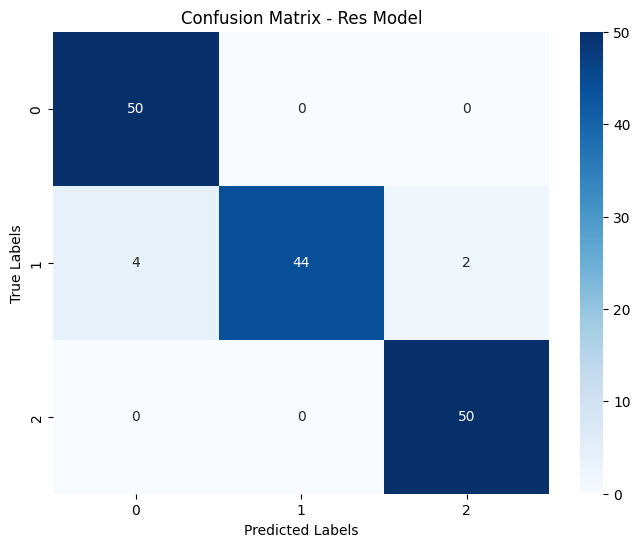

              precision    recall  f1-score   support

     class_0       0.98      0.90      0.94        50
     class_1       0.83      0.98      0.90        50
     class_2       1.00      0.90      0.95        50

    accuracy                           0.93       150
   macro avg       0.94      0.93      0.93       150
weighted avg       0.94      0.93      0.93       150



In [64]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_Res)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Res Model')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

# Classification Report
class_names = ['class_0', 'class_1', 'class_2']
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

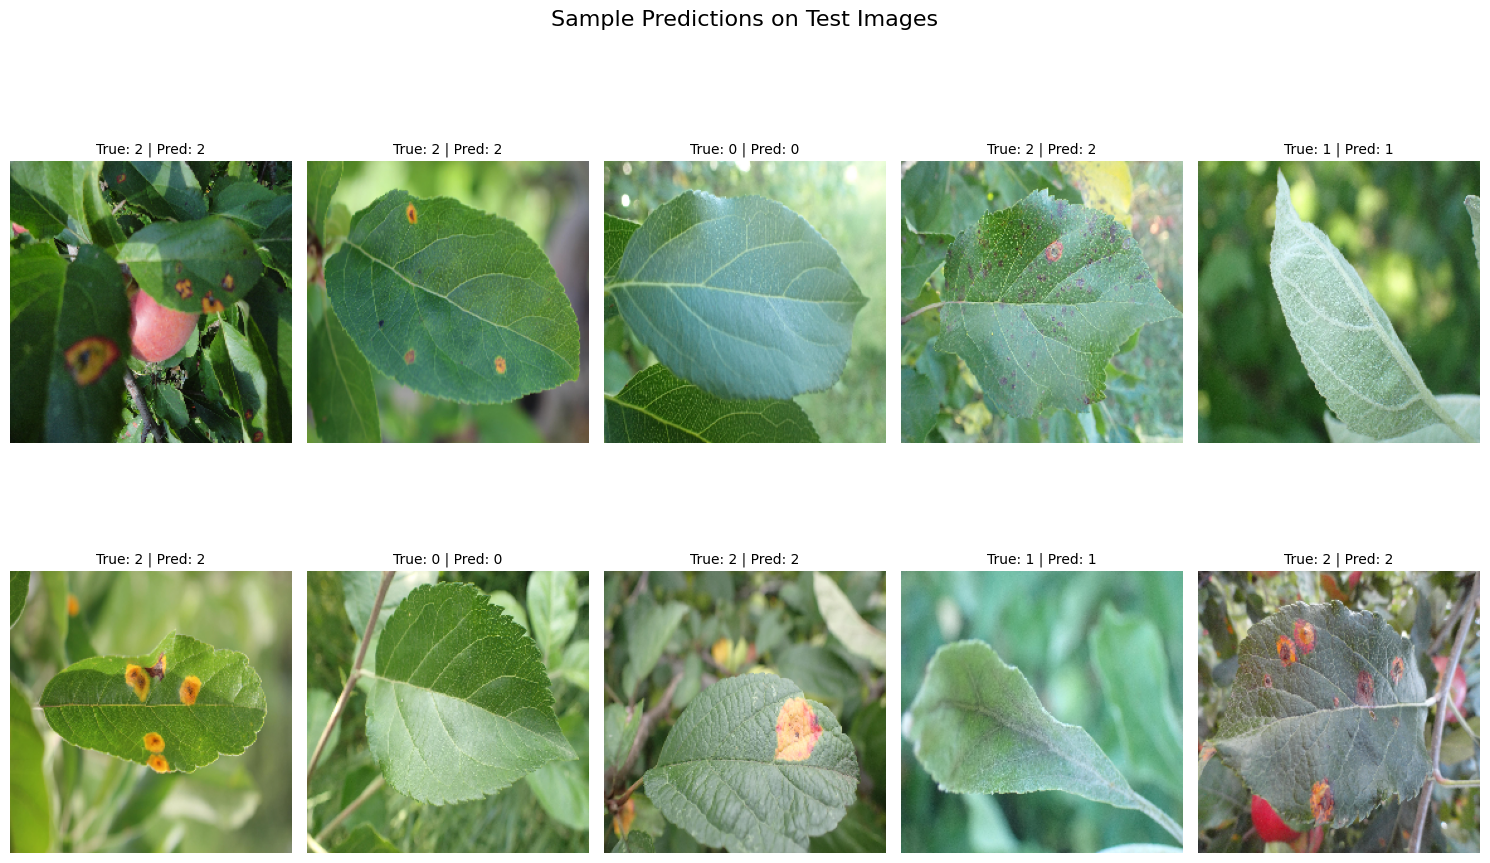

In [65]:
num_samples = 10

indices = np.random.choice(len(x_test_origin), num_samples, replace=False)

plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):
    img = x_test_origin[idx]
    true_label = y_test_encoded[idx]
    pred_label = y_pred_Res[idx]

    plt.subplot(2, 5, i + 1)
    plt.imshow(img.astype('uint8'))
    plt.axis('off')
    true_name = le.inverse_transform([true_label])[0]
    pred_name = le.inverse_transform([pred_label])[0]
    plt.title(f"True: {true_name} | Pred: {pred_name}", fontsize=10)
    plt.title(f"True: {true_label} | Pred: {pred_label}", fontsize=10)

plt.suptitle("Sample Predictions on Test Images", fontsize=16)
plt.tight_layout()
plt.show()

# ResNet is the best! Yayyyy ❤